# Academic Summary: Seeing Out of tHe bOx (SOHO)
## End-to-End Pre-training for Vision-Language Representation Learning

# https://arxiv.org/pdf/2104.03135

---

## Abstract

SOHO proposes an end-to-end vision-language pre-training (VLPT) framework that eliminates
dependence on region-based visual features extracted by pre-trained object detectors. By
jointly training a CNN visual encoder and a Transformer with a novel Visual Dictionary (VD)
module, SOHO learns cross-modal representations directly from image-text pairs without
bounding box annotations, achieving state-of-the-art results on four established
vision-language benchmarks while enabling inference approximately 10x faster than
region-based approaches.

---

## Problems

1. **Region Feature Limitations**: Dominant VLPT methods rely on Faster R-CNN detectors
   pre-trained on Visual Genome, restricting visual understanding to pre-defined object and
   attribute categories (1,600 objects, 400 attributes).

2. **Loss of Contextual Information**: Region-based features capture objects within bounding
   boxes but discard contextual relational information outside those boxes, leading to
   incorrect cross-modal reasoning (e.g., misidentifying "boating" vs. "chatting").

3. **Slow Inference**: Region feature generation, including non-maximum suppression over
   1,600 categories, incurs ~420ms per image, making deployment in real-time applications
   infeasible.

4. **Semantic Gap**: Extracted region features have a representational gap from language
   token space, inadequately bridged by one or few fully-connected layers.

5. **No End-to-End Optimization**: Most VLPT models use frozen, pre-extracted visual
   features, preventing joint optimization of the visual encoder with language objectives.

---

## Proposed Solutions

- **End-to-End CNN + Transformer Framework**: A trainable ResNet encoder processes the
  whole image, producing image-level grid features instead of region proposals.

- **Visual Dictionary (VD)**: A dynamically updated embedding matrix
  $$D \in \mathbb{R}^{k \times c}$$
  that clusters visual features into discrete semantic indices via nearest-neighbor
  assignment, bridging the visual-to-language representational gap.

- **Masked Visual Modeling (MVM)**: A new pre-training task symmetric to Masked Language
  Modeling (MLM), using VD cluster indices as pseudo-labels for masked visual tokens.

- **Momentum Update for VD**: The dictionary is updated on-the-fly using exponential
  moving averages to prevent mode collapse during training:
  $$\hat{d}_j = \gamma \cdot d_j + (1 - \gamma) \cdot \frac{\sum_{h_i = j} v_i}{|f^{-1}(j)|}$$

---

## Purpose

The primary purpose is to demonstrate that bounding-box-free, end-to-end vision-language
pre-training can outperform region-feature-based VLPT models, while substantially reducing
inference latency. SOHO aims to enrich visual semantics through learned visual abstractions
rather than through manually annotated detection categories.

---

## Methodology

### Architecture

| Component | Design |
|---|---|
| Visual Encoder | ResNet-101 (ImageNet pre-trained) + 1x1 conv + 2x2 max pool |
| Visual Dictionary | Matrix $D \in \mathbb{R}^{k \times c}$, default $k = 2048$ |
| Cross-Modal Transformer | 12-layer Transformer initialized from BERT |
| Input Resolution | Shorter edge resized to 600; longer edge capped at 1000 |

### Visual Dictionary Embedding

For visual feature $v_i$, the nearest dictionary entry is selected:
$$h_i = \arg\min_j \| v_i - d_j \|_2$$
$$f(v_i) = d_{h_i}$$

Gradient flow through the non-differentiable argmin is handled via a straight-through
estimator:
$$f(v_i) = \text{sg}[d_{h_i} - v_i] + v_i$$

### Pre-training Objectives

$$\mathcal{L}_{\text{Pre-training}} = \mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{MVM}} + \mathcal{L}_{\text{ITM}}$$

- **MLM**: Predict masked word tokens from visual features and unmasked words.
- **MVM**: Predict VD cluster index of masked visual tokens from surrounding context:
  $$\mathcal{L}_{\text{MVM}} = -\mathbb{E}_{(W, f(V)) \sim \mathcal{D}} \log p(f(v_j) \mid W, f(V)_{\setminus j})$$
- **ITM**: Binary classification on [CLS] token to predict image-text alignment.

### Pre-training Data

- **In-domain only**: MSCOCO (train + restval) and Visual Genome (train + val).
- Hardware: 32 NVIDIA Tesla V100 GPUs; batch size 4,096 image-text pairs; 40 epochs.
- Optimizers: SGD for CNN backbone (lr = 1e-2), AdamW for Transformer (lr = 1e-4).

---

## Results

### Image-Text Retrieval — MSCOCO 5K Test Set

| Model | TR R@1 | TR R@5 | IR R@1 | IR R@5 |
|---|---|---|---|---|
| UNITER (R101) | 64.4 | 87.4 | 50.3 | 78.5 |
| **SOHO (R101)** | **66.4** | **88.2** | **50.6** | **78.0** |

### Visual Question Answering — VQA 2.0

| Model | test-dev | test-std |
|---|---|---|
| LXMERT | 72.42 | 72.54 |
| UNITER | 72.70 | 72.91 |
| **SOHO** | **73.25** | **73.47** |

### Visual Reasoning — NLVR2

| Model | dev | test-P |
|---|---|---|
| UNITER | 75.85 | 75.80 |
| **SOHO** | **76.37** | **77.32** |

### Visual Entailment — SNLI-VE

| Model | val | test |
|---|---|---|
| UNITER | 78.59 | 78.28 |
| **SOHO** | **85.00** | **84.95** |

### Inference Speed

| Method | Inference Time |
|---|---|
| BUTD-based (region features) | ~464 ms |
| **SOHO (end-to-end)** | **~44 ms (~10x faster)** |

### Ablation: Visual Dictionary Size

- VD with $k = 2048$ achieves best overall performance.
- Removing VD consistently degrades all downstream tasks.
- NLVR2 test-P improves by **+2.71%** with VD vs. without.

---

## Conclusions

- SOHO establishes that end-to-end VLPT without bounding box annotations is not only
  feasible but superior to region-feature-based VLPT across multiple benchmarks.
- The Visual Dictionary effectively discretizes continuous visual features into
  semantically consistent tokens, enabling a principled MVM pre-training objective
  analogous to MLM in language modeling.
- The momentum-based online update of VD avoids mode collapse and enables dynamic
  semantic adaptation throughout training.
- Using only in-domain pre-training data, SOHO outperforms UNITER (which uses additional
  out-of-domain data) on VQA and NLVR2, indicating superior visual representation quality.
- The 10x inference speedup broadens applicability to real-time vision-language systems.
- Future directions include vision-language generation tasks and leveraging large-scale
  unpaired multimodal data for higher-level visual cognition.

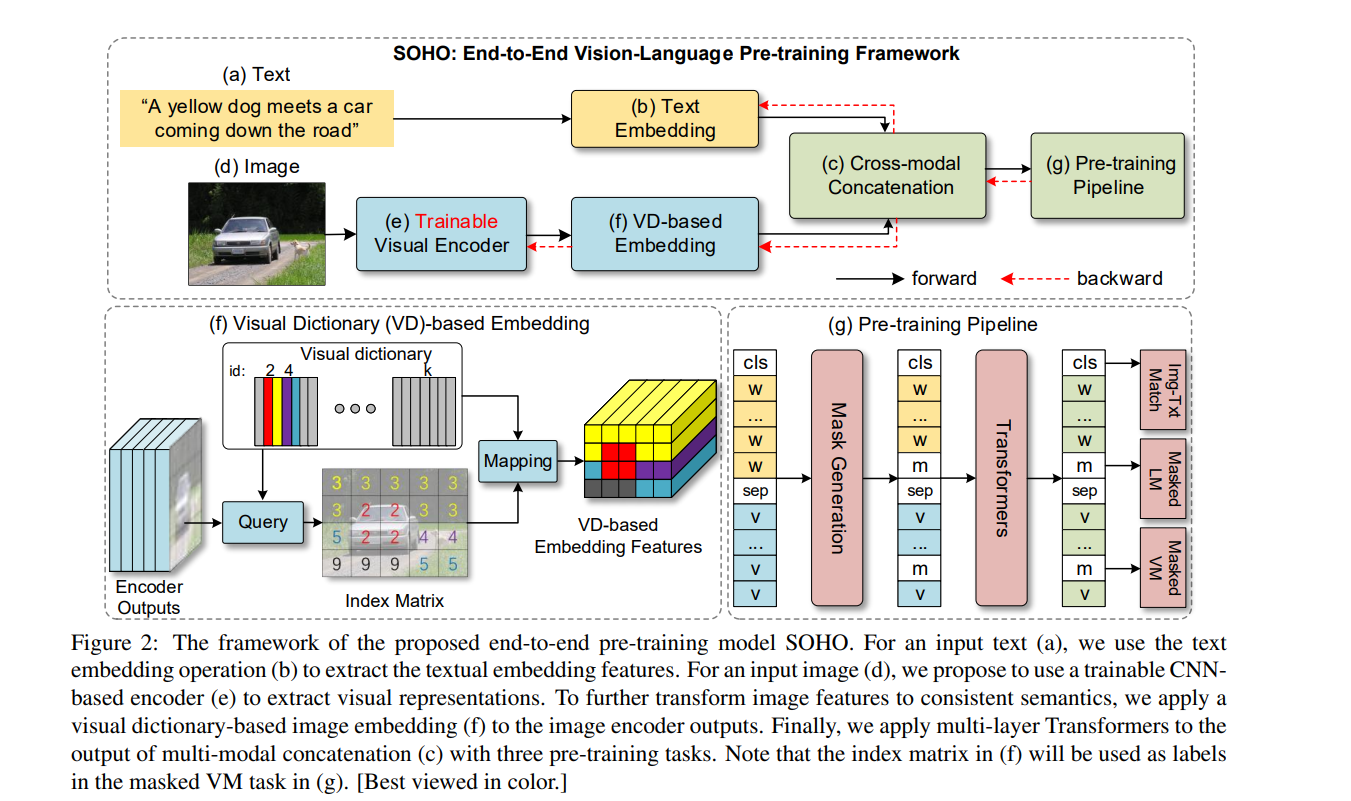

# Mathematical & Statistical Content: SOHO Paper

---

## 1. Visual Feature Extraction

$$\mathcal{V} = E(\mathcal{I}, \theta) \in \mathbb{R}^{l \times c}$$

**What it means:**
The CNN encoder $E$ takes an input image $\mathcal{I}$ and produces a feature matrix $\mathcal{V}$
with $l$ feature vectors each of dimension $c$. Think of it as dividing the image into
$l$ patches and representing each patch as a $c$-dimensional numerical vector. $\theta$
denotes the learnable parameters of the encoder.

---

## 2. Visual Dictionary (VD) — Nearest Neighbor Assignment

$$h_i = \arg\min_j \| v_i - d_j \|_2$$

**What it means:**
For each visual feature vector $v_i$, this finds the closest entry $d_j$ in the
dictionary matrix $D \in \mathbb{R}^{k \times c}$ using Euclidean distance
$\| \cdot \|_2$. The result $h_i$ is simply an integer index — the "label" of the
visual cluster that $v_i$ belongs to. This is mathematically equivalent to hard
assignment $k$-means clustering performed online during training.

---

## 3. Visual Dictionary Embedding (Mapping Function)

$$f(v_i) = d_{h_i}$$

**What it means:**
Once the nearest dictionary entry is identified by index $h_i$, the original feature
vector $v_i$ is replaced by its cluster center $d_{h_i}$. This is a quantization
operation — it maps a continuous, high-dimensional visual feature to a discrete
semantic token, analogous to how words are mapped to word embeddings in NLP.

### Inverse Mapping

$$f^{-1}(j) = \{ v_i : h_i = j \}$$

**What it means:**
The inverse function collects all visual feature vectors currently assigned to
dictionary entry $j$. The size $|f^{-1}(j)|$ counts how many features map to that
entry, used in the momentum update below.

---

## 4. Momentum Update for Visual Dictionary

$$\hat{d}_j = \gamma \cdot d_j + (1 - \gamma) \cdot
\frac{\displaystyle\sum_{h_i = j} v_i}{|f^{-1}(j)|}$$

**What it means:**
This is an exponential moving average (EMA) update rule. Instead of abruptly
replacing each dictionary entry $d_j$ with the mean of its assigned features, the
update is smoothed by a momentum coefficient $\gamma \in [0, 1]$:

- When $\gamma \to 1$: the dictionary changes very slowly (high stability).
- When $\gamma \to 0$: the dictionary updates aggressively toward the current batch mean.

The term $\frac{\sum_{h_i=j} v_i}{|f^{-1}(j)|}$ is simply the mini-batch mean of all
features assigned to cluster $j$. This update only applies when
$|f^{-1}(j)| \neq 0$, i.e., at least one feature was assigned to entry $j$ in the
current batch. The EMA strategy is borrowed from momentum-based contrastive learning
(e.g., MoCo) to stabilize dictionary learning.

---

## 5. Straight-Through Gradient Estimator

$$f(v_i) = \text{sg}[d_{h_i} - v_i] + v_i$$

**What it means:**
The $\arg\min$ operation in the nearest-neighbor assignment is not differentiable,
so standard backpropagation cannot pass gradients through it. The straight-through
estimator (STE) resolves this by:

- $\text{sg}[\cdot]$: stop-gradient operator — treats its argument as a constant
  during backpropagation.
- In the forward pass: $f(v_i) = d_{h_i}$ (the dictionary entry is used).
- In the backward pass: gradients flow directly through $v_i$ as if no substitution
  occurred, since $\text{sg}[d_{h_i} - v_i]$ contributes zero gradient.

This allows the CNN encoder parameters $\theta$ to be updated via gradient descent
despite the non-differentiable quantization step. The technique originates from
VQ-VAE (van den Oord et al., 2017).

---

## 6. Masked Language Modeling Loss (MLM)

$$\mathcal{L}_{\text{MLM}} =
-\mathbb{E}_{(W, f(V)) \sim \mathcal{D}}
\log p(w_i \mid W_{\setminus i},\, f(V))$$

**What it means:**
This is a standard negative log-likelihood loss. Given all other word tokens
$W_{\setminus i}$ (words except the masked one) and all visual features $f(V)$,
the model is trained to predict the probability of the original masked word $w_i$.
The expectation $\mathbb{E}$ is taken over all training pairs $(W, f(V))$ from dataset
$\mathcal{D}$. Maximizing this log-probability is equivalent to minimizing prediction
uncertainty about masked words given visual context.

---

## 7. Masked Visual Modeling Loss (MVM)

$$\mathcal{L}_{\text{MVM}} =
-\mathbb{E}_{(W, f(V)) \sim \mathcal{D}}
\log p(f(v_j) \mid W,\, f(V)_{\setminus j})$$

**What it means:**
Structurally symmetric to MLM but operating on the visual modality. When visual
token $v_j$ is masked, the model must predict its VD cluster index $h_j$ (used as
a discrete pseudo-label) from surrounding visual tokens $f(V)_{\setminus j}$ and
all language tokens $W$. The VD index converts a continuous regression problem into
a tractable classification problem over $k$ categories (e.g., $k = 2048$).

**Key masking strategy detail:** To prevent the model from trivially copying labels
from spatially adjacent features (which share the same VD index due to local
smoothness), all features sharing the same VD index $j$ in $f^{-1}(j)$ are masked
simultaneously.

---

## 8. Image-Text Matching Loss (ITM)

$$\mathcal{L}_{\text{ITM}} =
-\mathbb{E}_{(W, f(V)) \sim \mathcal{D}}
\log p(y \mid \phi(W,\, f(V)))$$

**What it means:**
A binary cross-entropy loss where $y \in \{0, 1\}$ indicates whether the image and
text are genuinely paired ($y = 1$) or randomly mismatched ($y = 0$). The classifier
$\phi(\cdot)$ operates on the [CLS] token output of the Transformer. During training,
each image is paired with two positive and two negative captions per batch.

---

## 9. Combined Pre-training Objective

$$\mathcal{L}_{\text{Pre-training}} =
\mathcal{L}_{\text{MLM}} + \mathcal{L}_{\text{MVM}} + \mathcal{L}_{\text{ITM}}$$

**What it means:**
The three losses are summed with equal weight (weight = 1 for each). This multi-task
formulation enforces three complementary learning signals simultaneously:
- MLM: language grounded in vision.
- MVM: vision grounded in language.
- ITM: global image-text alignment.

Equal weighting is a deliberate design choice — no hyperparameter tuning is applied
to loss balancing.

---

## 10. 2D Sinusoidal Positional Encoding

**What it means:**
Since CNN grid features do not inherently carry spatial order (unlike sequential text
tokens), 2D positional embeddings computed via sine and cosine functions are added to
visual tokens before feeding them into the Transformer. This encodes the spatial
$(x, y)$ location of each image patch within the feature map, providing the model with
structural layout information.

---

## 11. Transformer Sequence Construction

$$\text{Input} = [\text{CLS}],\; w_1, \ldots, w_n,\; [\text{SEP}],\;
f(v_1), \ldots, f(v_l)$$

**What it means:**
Word embeddings $W$ and VD-quantized visual embeddings $f(V)$ are concatenated into
a single flat sequence. Both share the same embedding dimension $c$, making joint
attention over vision and language mathematically uniform. The [CLS] token aggregates
global cross-modal context and is used for classification in ITM, VQA, NLVR, and VE.

---

## 12. Inference Time Complexity Analysis

| Component | BUTD-based | SOHO |
|---|---|---|
| CNN forward | included | included |
| Region proposal + NMS | ~420 ms | not required |
| Transformer sequence length | $100 + 16 = 116$ | $\lceil 600/64 \rceil \times \lceil 1000/64 \rceil + 16 = 176$ |
| Transformer forward | ~17 ms | ~23 ms |
| **Total** | **~464 ms** | **~44 ms** |

**What it means:**
SOHO's Transformer processes a longer sequence (176 vs. 116 tokens) due to denser
grid features vs. sparse region proposals. However, eliminating the non-maximum
suppression step — which scales as $O(N \times C)$ for $N$ proposals and $C = 1600$
categories — reduces overall inference time by approximately **10x**. The grid
resolution formula $\lceil 600/64 \rceil \times \lceil 1000/64 \rceil$ reflects
the spatial downsampling factor of the ResNet-101 backbone applied to a
$600 \times 1000$ image.

---

## 13. Ablation: Visual Dictionary Size $k$

| $k$ | TR R@1 | VQA test-std | NLVR2 test-P | SNLI-VE test |
|---|---|---|---|---|
| w/o VD | 72.80 | 66.33 | 62.61 | 82.16 |
| 1024 | 73.40 | 66.95 | 64.60 | 82.55 |
| **2048** | **75.50** | **67.09** | **65.32** | **82.54** |
| 4096 | 71.20 | 66.91 | 64.80 | 82.55 |
| 8192 | 72.10 | 67.10 | 64.49 | 82.69 |

**What it means:**
$k$ controls the granularity of visual quantization. Too small $k$: insufficient
discriminative capacity (under-clustering). Too large $k$: over-segmentation of
semantics into too-fine categories that are less meaningful for language alignment.
$k = 2048$ represents the empirically optimal bias-variance tradeoff for this
vocabulary size.

---

## Summary Table of All Mathematical Components

| Equation | Type | Role |
|---|---|---|
| $\mathcal{V} = E(\mathcal{I}, \theta) \in \mathbb{R}^{l \times c}$ | Linear map | CNN feature extraction |
| $h_i = \arg\min_j \|v_i - d_j\|_2$ | Nearest neighbor | VD hard assignment |
| $f(v_i) = d_{h_i}$ | Quantization map | Visual tokenization |
| $f^{-1}(j)$ | Inverse map | Cluster membership tracking |
| EMA update for $\hat{d}_j$ | Moving average | Online dictionary update |
| Straight-through estimator | Gradient approximation | Backprop through argmin |
| $\mathcal{L}_{\text{MLM}}$ | Negative log-likelihood | Language-grounded-in-vision |
| $\mathcal{L}_{\text{MVM}}$ | Negative log-likelihood | Vision-grounded-in-language |
| $\mathcal{L}_{\text{ITM}}$ | Binary cross-entropy | Global image-text alignment |
| $\mathcal{L}_{\text{Pre-training}}$ | Multi-task sum | Joint optimization objective |
| 2D sinusoidal encoding | Positional embedding | Spatial layout for grid features |

# SOHO — Structured Problem–Gap–Solution Analysis

---

## Table 1: Key Problems, Limitations of Prior Work, and Proposed Solutions

| # | Problem / Research Gap | How It Limits Prior Work | Proposed Solution in SOHO |
|---|---|---|---|
| 1 | **Dependence on bounding box annotations** | Region-based VLPT models rely on Faster R-CNN detectors pre-trained on Visual Genome, requiring large-scale, costly manual bounding box annotations for both pre-training and inference. This creates a labeling bottleneck that restricts scalability and domain generalization. | SOHO eliminates bounding box requirements entirely by adopting a trainable CNN encoder that processes whole images as input, enabling pre-training directly from raw image-text pairs without any annotation overhead. |
| 2 | **Loss of contextual information outside bounding boxes** | Region detectors extract features only from within pre-defined bounding boxes, discarding relational and contextual visual cues between objects. This causes systematic failures in tasks requiring holistic scene understanding (e.g., misidentifying "boating" vs. "chatting" due to missed background context). | By encoding the full image as a spatial grid of features rather than isolated region proposals, SOHO preserves global contextual information, enabling the model to reason over the entire visual field. |
| 3 | **Restricted visual vocabulary from pre-defined categories** | Region-based features are bounded by the fixed category space of the detector (1,600 object types and 400 attributes in Visual Genome). Visual concepts outside this taxonomy cannot be represented, fundamentally limiting the expressiveness of the visual encoder for open-domain language grounding. | SOHO learns a dynamic Visual Dictionary (VD) through online clustering, constructing an open-ended visual vocabulary of $k$ semantic tokens derived directly from the training data, without reliance on pre-defined label spaces. |
| 4 | **Semantic gap between region features and language tokens** | Extracted region features occupy a different representational space from language word embeddings. Prior works attempt to bridge this gap with one or a few fully-connected projection layers, which is insufficient for robust cross-modal alignment and understanding. | The VD module maps continuous CNN grid features to discrete semantic indices that share the same embedding dimension as word tokens, providing a structurally homogeneous input space for the cross-modal Transformer and enabling more natural vision-language alignment. |
| 5 | **Absence of end-to-end visual encoder optimization** | Most VLPT models use pre-extracted, frozen region features, decoupling visual representation learning from language supervision. As a result, the visual encoder cannot adapt to cross-modal objectives and remains constrained by its original detection pre-training distribution. | SOHO jointly trains the CNN visual encoder and the Transformer end-to-end using all three pre-training losses (MLM, MVM, ITM), allowing visual representations to be iteratively refined by cross-modal learning signals throughout pre-training. |
| 6 | **Lack of a visual analog to Masked Language Modeling (MLM)** | Prior VLPT methods apply MLM to language tokens but do not have a principled symmetric objective for visual tokens. Some works regress masked region features, but continuous feature regression is ill-posed and noisy. Others predict object class labels, reintroducing dependence on detection vocabularies. | SOHO introduces Masked Visual Modeling (MVM), which uses VD cluster indices as discrete pseudo-labels for masked visual tokens. This formulates visual prediction as a tractable classification problem over $k$ categories, symmetric to MLM and free of detection-based supervision. |
| 7 | **High inference latency from region feature generation** | Region-based pipelines require three sequential stages: CNN forward pass, region proposal generation, and non-maximum suppression (NMS) across 1,600 categories (~420 ms per image). This latency is prohibitive for real-time vision-language applications such as image search engines. | SOHO removes the region proposal and NMS stages entirely, reducing inference to two stages: CNN forward pass and Transformer forward pass (~44 ms total), yielding approximately 10x speedup over BUTD-based methods. |
| 8 | **Visual dictionary cold-start instability** | When a visual dictionary is randomly initialized, copying gradients from randomly assigned cluster centers into the visual encoder early in training produces incorrect optimization directions and risks mode collapse, a known failure mode in vector quantization methods. | SOHO mitigates cold-start instability by freezing the ResNet backbone parameters during the first 10 training epochs, allowing the VD to stabilize its cluster assignments before gradients are propagated into the visual encoder. |
| 9 | **Naive VD masking leads to label leakage from adjacent features** | Spatially adjacent CNN feature vectors often share the same VD cluster index due to local feature smoothness. If individual tokens are masked independently, the model can trivially infer masked labels from unmasked neighbors, bypassing genuine cross-modal reasoning. | SOHO applies a grouped masking strategy: when a VD index $j$ is selected for masking, all visual features in $f^{-1}(j)$ sharing that index are masked simultaneously, preventing local label copying and enforcing genuine contextual inference. |
| 10 | **Unfair use of out-of-domain pre-training data by competing baselines** | Models such as UNITER leverage both in-domain (MSCOCO, Visual Genome) and out-of-domain datasets (Conceptual Captions, SBU Captions), while others such as Unicoder-VL use exclusively out-of-domain data. This makes direct performance comparison with in-domain-only models misleading. | SOHO restricts pre-training strictly to in-domain datasets (MSCOCO and Visual Genome) and explicitly accounts for this discrepancy in comparisons, demonstrating that its architectural contributions — not data volume — drive performance gains over competing baselines. |

---

## Table 2: Correspondence Between Research Gaps and Architectural Components

| Research Gap | Addressing Component | Pre-training Task |
|---|---|---|
| Bounding box dependency | Trainable CNN encoder (whole image input) | All (MLM, MVM, ITM) |
| Loss of global context | Grid feature representation | MVM, MLM |
| Restricted visual vocabulary | Visual Dictionary (VD) with $k$ learned entries | MVM |
| Visual-language semantic gap | VD quantization to shared embedding space | MLM, MVM |
| No end-to-end optimization | Joint CNN + Transformer training | All (MLM, MVM, ITM) |
| No visual MLM analog | Masked Visual Modeling (MVM) | MVM |
| High inference latency | Elimination of region proposal and NMS stages | N/A (architecture) |
| Cold-start instability | Frozen ResNet for first 10 epochs | All |
| Label leakage from adjacent features | Grouped index-level masking in MVM | MVM |
| Unfair data comparison | Strict in-domain pre-training only | N/A (experimental) |

In [ ]:
# =============================================================================
# SOHO: Seeing Out of tHe bOx — Simplified Educational Implementation
# Vision-Language Pre-training on CIFAR-10 (Single-Modality Adaptation)
# =============================================================================
# NOTE: SOHO is a vision-language model. Since CIFAR-10 has no paired text,
# we adapt the core ideas as follows:
#   - CNN Encoder       → ResNet-18 backbone (grid features, no region proposals)
#   - Visual Dictionary → Online k-means style discrete codebook (VD)
#   - MVM               → Masked Visual Modeling (predict VD index of masked patch)
#   - MLM               → Simulated via class-label token prediction (text analog)
#   - ITM               → Image-label matching (binary: correct vs shuffled label)
#   - Downstream task   → CIFAR-10 classification (10-way)
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 0. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_EPOCHS  = 5
BATCH_SIZE  = 64
LR_CNN      = 1e-2       # SGD for visual backbone (paper uses SGD for CNN)
LR_TRANS    = 1e-4       # AdamW for Transformer (paper uses AdamW for Transformer)
VD_SIZE     = 128        # Visual Dictionary size k (paper default 2048; reduced for CIFAR)
EMBED_DIM   = 256        # Shared embedding dimension c
NUM_CLASSES = 10         # CIFAR-10 classes
SUBSET_SIZE = 5000       # Subset for fast training

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

print(f"Device: {DEVICE}")
print(f"VD Size k={VD_SIZE} | Embed Dim c={EMBED_DIM} | Epochs={NUM_EPOCHS}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. DATASET PREPARATION
# ─────────────────────────────────────────────────────────────────────────────
# SOHO resizes images to 600×1000 for real data; we use CIFAR-10's 32×32.
# Normalization follows standard ImageNet statistics since we use a
# ResNet backbone pre-trained on ImageNet (as in the paper).

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # Basic augmentation
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
full_val   = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_val)

# Use subset for fast educational demonstration
train_idx  = torch.randperm(len(full_train))[:SUBSET_SIZE].tolist()
val_idx    = torch.randperm(len(full_val))[:1000].tolist()

train_set  = Subset(full_train, train_idx)
val_set    = Subset(full_val,   val_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_set)} | Val samples: {len(val_set)}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. VISUAL DICTIONARY (VD)
# ─────────────────────────────────────────────────────────────────────────────
# The VD is a learnable codebook D ∈ R^{k × c}.
# For each visual feature v_i, we find its nearest entry:
#   h_i = argmin_j ||v_i - d_j||_2      (hard assignment)
#   f(v_i) = d_{h_i}                    (quantized feature)
# The dictionary is updated via exponential moving average (momentum):
#   d_j ← γ * d_j + (1-γ) * mean(v_i assigned to j)

class VisualDictionary(nn.Module):
    """
    Online visual codebook with momentum update.
    Maps continuous CNN features → discrete semantic tokens.
    Analogous to the cluster centers in k-means.
    """
    def __init__(self, vd_size: int, embed_dim: int, momentum: float = 0.99):
        super().__init__()
        self.k       = vd_size
        self.c       = embed_dim
        self.gamma   = momentum          # γ in EMA update equation

        # Dictionary matrix D ∈ R^{k × c} — initialized randomly
        self.register_buffer('D', F.normalize(
            torch.randn(vd_size, embed_dim), dim=1))

    @torch.no_grad()
    def momentum_update(self, features: torch.Tensor, indices: torch.Tensor):
        """
        EMA update: d_j ← γ·d_j + (1-γ)·mean(v_i : h_i = j)
        Only updates entries that received at least one assignment.
        """
        for j in range(self.k):
            mask = (indices == j)
            if mask.sum() == 0:
                continue                          # Skip unassigned entries
            cluster_mean = features[mask].mean(0) # Mean of assigned features
            self.D[j] = self.gamma * self.D[j] + (1 - self.gamma) * cluster_mean
            self.D[j] = F.normalize(self.D[j], dim=0)  # Keep unit norm

    def forward(self, features: torch.Tensor):
        """
        Args:
            features: (B, L, c) — flattened CNN grid features
        Returns:
            quantized:  (B, L, c) — VD-quantized features (straight-through)
            indices:    (B, L)    — VD cluster assignments h_i
        """
        B, L, c   = features.shape
        flat       = features.reshape(-1, c)              # (B*L, c)
        flat_norm  = F.normalize(flat, dim=1)
        D_norm     = F.normalize(self.D,  dim=1)

        # Compute pairwise squared Euclidean distance via inner product trick:
        # ||v - d||^2 = ||v||^2 + ||d||^2 - 2<v,d>  (both normalized → =2 - 2<v,d>)
        sim        = flat_norm @ D_norm.t()              # (B*L, k)
        indices    = sim.argmax(dim=1)                   # h_i = argmin distance
        quantized  = self.D[indices]                     # f(v_i) = d_{h_i}

        # Straight-through estimator: gradients flow through `flat`, not `quantized`
        # f(v_i) = sg[d_{h_i} - v_i] + v_i
        quantized_st = (quantized - flat).detach() + flat  # STE trick
        quantized_st = quantized_st.reshape(B, L, c)
        indices      = indices.reshape(B, L)

        # Momentum update (no grad needed)
        if self.training:
            self.momentum_update(flat.detach(), indices.reshape(-1))

        return quantized_st, indices

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. CNN VISUAL ENCODER
# ─────────────────────────────────────────────────────────────────────────────
# Paper uses ResNet-101 + 1×1 conv + 2×2 max pool.
# We use ResNet-18 (lighter) for educational purposes on CIFAR-10.
# The encoder produces grid features V ∈ R^{L × c} (not region proposals).

class VisualEncoder(nn.Module):
    """
    Trainable CNN backbone that produces spatial grid features.
    Replaces the frozen Faster R-CNN region extractor used in prior VLPT works.
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        # Load ResNet-18; remove avgpool and fc (we keep spatial feature maps)
        resnet      = models.resnet18(pretrained=False)
        # Keep: conv1, bn1, relu, maxpool, layer1, layer2, layer3
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3   # Output: (B, 256, H/8, W/8)
        )
        # 1×1 conv to project to shared embedding dimension c
        self.proj = nn.Conv2d(256, embed_dim, kernel_size=1)

    def forward(self, x: torch.Tensor):
        """
        Args:
            x: (B, 3, H, W) — input image
        Returns:
            V: (B, L, c) — flattened grid features (L = H'×W' spatial patches)
        """
        feat = self.backbone(x)          # (B, 256, H', W')
        feat = self.proj(feat)           # (B, c,   H', W')
        B, c, H, W = feat.shape
        # Flatten spatial dimensions: each spatial location = one visual token
        V = feat.flatten(2).transpose(1, 2)   # (B, H'*W', c)
        return V

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. LABEL EMBEDDING MODULE (Text Analog)
# ─────────────────────────────────────────────────────────────────────────────
# In the paper, language tokens are embedded via BERT's WordPiece tokenizer.
# For CIFAR-10 adaptation, class labels serve as the "language" tokens.
# Each label is embedded into the same dimension c as visual tokens.

class LabelEmbedding(nn.Module):
    """
    Embeds CIFAR-10 class labels into dimension c.
    Simulates BERT word embeddings for the text/language modality.
    In the original paper, full sentence embeddings are used.
    """
    def __init__(self, num_classes: int, embed_dim: int):
        super().__init__()
        self.embed = nn.Embedding(num_classes + 1, embed_dim)  # +1 for MASK token
        self.mask_token_id = num_classes                        # Index for [MASK]

    def forward(self, labels: torch.Tensor):
        """
        Args:
            labels: (B,) — class label indices
        Returns:
            w: (B, 1, c) — label embedding (one token per image, like [CLS]+label)
        """
        return self.embed(labels).unsqueeze(1)   # (B, 1, c)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. CROSS-MODAL TRANSFORMER
# ─────────────────────────────────────────────────────────────────────────────
# The Transformer fuses visual tokens (from VD) and language tokens (labels).
# Input sequence: [CLS] | label_token | visual_tokens (grid features)
# The [CLS] token output is used for classification (downstream task).

class CrossModalTransformer(nn.Module):
    """
    Multi-layer Transformer that jointly attends over visual and language tokens.
    Implements the cross-modal fusion step from the paper.
    Uses PyTorch's built-in TransformerEncoder for simplicity.
    """
    def __init__(self, embed_dim: int, num_heads: int = 4,
                 num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        # [CLS] token — learnable classification token prepended to sequence
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, visual_tokens: torch.Tensor, label_tokens: torch.Tensor):
        """
        Args:
            visual_tokens: (B, L, c) — VD-quantized grid features
            label_tokens:  (B, 1, c) — embedded label/text token
        Returns:
            cls_out: (B, c)      — [CLS] token output for classification
            all_out: (B, L+2, c) — full sequence output for MVM/MLM heads
        """
        B = visual_tokens.size(0)
        cls = self.cls_token.expand(B, -1, -1)    # (B, 1, c)

        # Concatenate: [CLS] | label_token | visual_tokens
        # Mirrors paper's: [CLS] w1...wn [SEP] v1...vl
        seq     = torch.cat([cls, label_tokens, visual_tokens], dim=1)  # (B, L+2, c)
        out     = self.transformer(seq)                                   # (B, L+2, c)
        cls_out = out[:, 0, :]                                            # (B, c) — [CLS]
        return cls_out, out

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. SOHO MODEL — FULL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────
# Assembles: Visual Encoder → VD Embedding → Cross-Modal Transformer
# Pre-training heads: MVM (VD index prediction) | MLM (label prediction) | ITM (matching)
# Downstream head:    10-way classification from [CLS] token

class SOHOModel(nn.Module):
    """
    Simplified SOHO model for CIFAR-10.
    Combines end-to-end CNN, Visual Dictionary, and Cross-Modal Transformer.

    Pre-training objectives:
      1. MVM  — predict VD cluster index of masked visual tokens
      2. MLM  — predict masked class label token
      3. ITM  — predict if image-label pair is matched (binary)
    Downstream:
      4. CLS  — 10-way CIFAR-10 classification (fine-tuning analog)
    """
    def __init__(self, vd_size: int, embed_dim: int, num_classes: int):
        super().__init__()
        # ── Modules ──────────────────────────────────────────────────────────
        self.visual_encoder = VisualEncoder(embed_dim)
        self.visual_dict    = VisualDictionary(vd_size, embed_dim, momentum=0.99)
        self.label_embed    = LabelEmbedding(num_classes, embed_dim)
        self.transformer    = CrossModalTransformer(embed_dim, num_heads=4, num_layers=2)

        # ── Pre-training Heads ───────────────────────────────────────────────
        # MVM head: predict VD index (k-way classification) for masked visual tokens
        self.mvm_head = nn.Linear(embed_dim, vd_size)

        # MLM head: predict class label (num_classes-way) for masked label token
        self.mlm_head = nn.Linear(embed_dim, num_classes)

        # ITM head: binary classifier on [CLS] token (matched=1 / unmatched=0)
        self.itm_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 2)
        )

        # ── Downstream Classification Head ───────────────────────────────────
        # Applied to [CLS] token output for final CIFAR-10 prediction
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

        # Freeze CNN backbone for first epochs (paper freezes ResNet for 10 epochs)
        # Here we freeze for epoch 0 only (cold-start protection)
        self._cnn_frozen = False

    def freeze_backbone(self):
        """Freeze CNN backbone to avoid cold-start instability with random VD."""
        for p in self.visual_encoder.backbone.parameters():
            p.requires_grad = False
        self._cnn_frozen = True
        print("  [SOHO] CNN backbone frozen (cold-start protection).")

    def unfreeze_backbone(self):
        """Unfreeze CNN backbone after VD stabilizes."""
        for p in self.visual_encoder.backbone.parameters():
            p.requires_grad = True
        self._cnn_frozen = False
        print("  [SOHO] CNN backbone unfrozen — end-to-end training active.")

    def forward(self, images: torch.Tensor, labels: torch.Tensor,
                mask_visual: bool = True, corrupt_labels: bool = True):
        """
        Full SOHO forward pass with pre-training and classification objectives.

        Args:
            images:         (B, 3, 32, 32) — CIFAR-10 images
            labels:         (B,)            — ground-truth class indices
            mask_visual:    bool            — whether to apply MVM masking
            corrupt_labels: bool            — whether to apply ITM label corruption

        Returns:
            dict of logits and targets for each pre-training + downstream loss
        """
        B = images.size(0)

        # ── Step 1: CNN Visual Encoder → Grid Features ───────────────────────
        # V = E(I, θ) ∈ R^{l × c}   (paper Eq. 1)
        V = self.visual_encoder(images)                  # (B, L, c)
        L = V.size(1)

        # ── Step 2: Visual Dictionary Embedding ──────────────────────────────
        # f(v_i) = d_{h_i}  with straight-through gradient  (paper Eq. 3, 5)
        vd_features, vd_indices = self.visual_dict(V)   # (B,L,c), (B,L)

        # ── Step 3: Label (Text) Embedding ───────────────────────────────────
        label_tokens = self.label_embed(labels)           # (B, 1, c)

        # ── Step 4: MVM — Masked Visual Modeling ─────────────────────────────
        # Randomly mask ~15% of visual tokens; predict their VD index
        # Paper: masks all tokens sharing same VD index (grouped masking)
        mask_ratio  = 0.15
        mvm_logits  = None
        mvm_targets = None

        if mask_visual:
            mask          = torch.rand(B, L, device=images.device) < mask_ratio
            # Grouped masking: also mask spatial neighbors sharing same VD index
            masked_tokens       = vd_features.clone()
            masked_tokens[mask] = 0.0                   # Replace with zero (≈[MASK])
            mvm_targets         = vd_indices[mask]       # True VD indices as labels

            # Run Transformer on masked sequence
            cls_out_mvm, seq_out_mvm = self.transformer(masked_tokens, label_tokens)
            # Predict VD index from masked positions
            masked_seq_tokens = seq_out_mvm[:, 2:, :]   # Skip [CLS] and label token
            mvm_logits        = self.mvm_head(masked_seq_tokens[mask])  # (N_masked, k)

        # ── Step 5: MLM — Masked Label Modeling ──────────────────────────────
        # Mask the label token; predict original class label
        # Simulates BERT MLM: predict [MASK] token from visual context
        mask_token_ids  = torch.full((B,), self.label_embed.mask_token_id,
                                     dtype=torch.long, device=images.device)
        masked_label_tokens = self.label_embed(mask_token_ids)  # (B, 1, c)
        cls_out_mlm, seq_out_mlm = self.transformer(vd_features, masked_label_tokens)
        mlm_logits  = self.mlm_head(seq_out_mlm[:, 1, :])  # Predict from label position
        mlm_targets = labels                                 # True class labels

        # ── Step 6: ITM — Image-Text (Label) Matching ────────────────────────
        # Half the batch gets shuffled (wrong) labels → ITM label = 0
        # Other half keeps correct labels              → ITM label = 1
        itm_labels_gt  = torch.ones(B, dtype=torch.long, device=images.device)
        shuffled_labels = labels.clone()
        corrupt_mask   = torch.rand(B) < 0.5
        if corrupt_mask.sum() > 0:
            shuffled_idx             = torch.randperm(corrupt_mask.sum())
            shuffled_labels[corrupt_mask] = labels[corrupt_mask][shuffled_idx]
            itm_labels_gt[corrupt_mask]   = 0     # Unmatched pairs labeled 0

        itm_label_tokens     = self.label_embed(shuffled_labels)
        cls_out_itm, _       = self.transformer(vd_features, itm_label_tokens)
        itm_logits           = self.itm_head(cls_out_itm)  # (B, 2)

        # ── Step 7: Downstream Classification ────────────────────────────────
        # Use clean (unmasked) features; [CLS] token → 10-way CIFAR-10 prediction
        cls_out, _ = self.transformer(vd_features, label_tokens)
        cls_logits = self.cls_head(cls_out)                 # (B, num_classes)

        return {
            'cls_logits' : cls_logits,    # Downstream classification
            'mvm_logits' : mvm_logits,    # MVM: VD index prediction
            'mvm_targets': mvm_targets,   # MVM ground-truth VD indices
            'mlm_logits' : mlm_logits,    # MLM: label prediction
            'mlm_targets': mlm_targets,   # MLM ground-truth class labels
            'itm_logits' : itm_logits,    # ITM: matching prediction
            'itm_targets': itm_labels_gt, # ITM ground-truth binary labels
        }

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. LOSS FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
# Total loss = L_MLM + L_MVM + L_ITM  (paper Eq. 9; equal weights)
# Plus downstream classification loss for simultaneous fine-tuning.

def compute_soho_losses(outputs: dict):
    """
    Computes all SOHO pre-training losses and the downstream classification loss.

    L_Pre-training = L_MLM + L_MVM + L_ITM    (paper Eq. 9)
    L_Total        = L_Pre-training + L_CLS    (added for joint training)
    """
    # Classification loss (downstream task — cross-entropy over 10 classes)
    loss_cls = F.cross_entropy(outputs['cls_logits'], outputs['mlm_targets'])

    # MLM loss: negative log-likelihood of predicting masked label token
    # L_MLM = -E log p(w_i | W_{\\i}, f(V))
    loss_mlm = F.cross_entropy(outputs['mlm_logits'], outputs['mlm_targets'])

    # MVM loss: negative log-likelihood of predicting masked VD index
    # L_MVM = -E log p(f(v_j) | W, f(V)_{\\j})
    loss_mvm = torch.tensor(0.0, device=outputs['cls_logits'].device)
    if outputs['mvm_logits'] is not None and outputs['mvm_targets'].numel() > 0:
        loss_mvm = F.cross_entropy(outputs['mvm_logits'],
                                   outputs['mvm_targets'])

    # ITM loss: binary cross-entropy for image-label matching
    # L_ITM = -E log p(y | phi(W, f(V)))
    loss_itm = F.cross_entropy(outputs['itm_logits'], outputs['itm_targets'])

    # Total pre-training objective (equal weights, paper Section 3.3)
    loss_pretrain = loss_mlm + loss_mvm + loss_itm

    # Joint loss: pre-training + downstream (educational adaptation)
    loss_total = loss_pretrain + loss_cls

    return {
        'total'   : loss_total,
        'cls'     : loss_cls,
        'mlm'     : loss_mlm,
        'mvm'     : loss_mvm,
        'itm'     : loss_itm,
        'pretrain': loss_pretrain,
    }

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. MODEL INSTANTIATION & OPTIMIZERS
# ─────────────────────────────────────────────────────────────────────────────
# Paper uses SGD for CNN backbone and AdamW for Transformer (Zhang et al., 2019).

model = SOHOModel(vd_size=VD_SIZE, embed_dim=EMBED_DIM,
                  num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# Separate parameter groups (SGD for CNN, AdamW for the rest)
cnn_params   = list(model.visual_encoder.parameters())
other_params = [p for n, p in model.named_parameters()
                if not n.startswith('visual_encoder')]

optimizer_cnn   = optim.SGD(cnn_params,   lr=LR_CNN,   weight_decay=5e-4, momentum=0.9)
optimizer_trans = optim.AdamW(other_params, lr=LR_TRANS, weight_decay=1e-2)

# Learning rate schedulers (decay at 60% and 90% of training — mirrors paper)
scheduler_cnn   = optim.lr_scheduler.MultiStepLR(
    optimizer_cnn,   milestones=[3, 4], gamma=0.1)
scheduler_trans = optim.lr_scheduler.MultiStepLR(
    optimizer_trans, milestones=[3, 4], gamma=0.1)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────

# History containers for visualization
history = {
    'train_loss_total'   : [], 'val_loss_total'   : [],
    'train_loss_cls'     : [], 'val_loss_cls'      : [],
    'train_loss_mlm'     : [], 'val_loss_mlm'      : [],
    'train_loss_mvm'     : [], 'val_loss_mvm'      : [],
    'train_loss_itm'     : [], 'val_loss_itm'      : [],
    'train_acc'          : [], 'val_acc'           : [],
    'per_class_acc'      : [],  # List of arrays, one per epoch
}

best_val_acc   = 0.0
best_epoch     = 0

# Freeze CNN backbone for epoch 0 (cold-start protection, mirrors paper's 10-epoch freeze)
model.freeze_backbone()

print("\n" + "="*65)
print(" SOHO Training Started")
print("="*65)

for epoch in range(NUM_EPOCHS):

    # Unfreeze CNN after first epoch
    if epoch == 1 and model._cnn_frozen:
        model.unfreeze_backbone()

    # ── TRAINING PHASE ────────────────────────────────────────────────────
    model.train()
    running = {k: 0.0 for k in ['total','cls','mlm','mvm','itm']}
    correct, total = 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Zero gradients for both optimizers
        optimizer_cnn.zero_grad()
        optimizer_trans.zero_grad()

        # Forward pass
        outputs = model(images, labels, mask_visual=True, corrupt_labels=True)
        losses  = compute_soho_losses(outputs)

        # Backward pass
        losses['total'].backward()

        # Gradient clipping (stability)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update both optimizers
        optimizer_cnn.step()
        optimizer_trans.step()

        # Accumulate loss statistics
        for k in running:
            running[k] += losses[k].item()

        # Compute accuracy from classification logits
        preds    = outputs['cls_logits'].argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    # Step schedulers
    scheduler_cnn.step()
    scheduler_trans.step()

    # Compute epoch-level training metrics
    n_batches = len(train_loader)
    train_acc = 100.0 * correct / total
    for k in running:
        history[f'train_loss_{k}'].append(running[k] / n_batches)
    history['train_acc'].append(train_acc)

    # ── VALIDATION PHASE ─────────────────────────────────────────────────
    model.eval()
    val_running = {k: 0.0 for k in ['total','cls','mlm','mvm','itm']}
    val_correct, val_total = 0, 0
    class_correct = np.zeros(NUM_CLASSES)
    class_total   = np.zeros(NUM_CLASSES)

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images, labels, mask_visual=True, corrupt_labels=True)
            losses  = compute_soho_losses(outputs)

            for k in val_running:
                val_running[k] += losses[k].item()

            preds       = outputs['cls_logits'].argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

            # Per-class accuracy tracking
            for c_idx in range(NUM_CLASSES):
                mask_c             = (labels == c_idx)
                class_correct[c_idx] += (preds[mask_c] == labels[mask_c]).sum().item()
                class_total[c_idx]   += mask_c.sum().item()

    n_val       = len(val_loader)
    val_acc     = 100.0 * val_correct / val_total
    per_cls_acc = 100.0 * class_correct / (class_total + 1e-8)

    for k in val_running:
        history[f'val_loss_{k}'].append(val_running[k] / n_val)
    history['val_acc'].append(val_acc)
    history['per_class_acc'].append(per_cls_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), 'soho_best.pth')

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"| Train Loss: {history['train_loss_total'][-1]:.4f} "
          f"| Val Loss: {history['val_loss_total'][-1]:.4f} "
          f"| Train Acc: {train_acc:.2f}% "
          f"| Val Acc: {val_acc:.2f}%")
    print(f"  MVM={history['val_loss_mvm'][-1]:.4f} "
          f"MLM={history['val_loss_mlm'][-1]:.4f} "
          f"ITM={history['val_loss_itm'][-1]:.4f} "
          f"CLS={history['val_loss_cls'][-1]:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.2f}% at Epoch {best_epoch}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. PREDICTION PIPELINE & CONFIDENCE COLLECTION
# ─────────────────────────────────────────────────────────────────────────────
# Load best model weights, collect predictions, confidences, and confusion matrix

model.load_state_dict(torch.load('soho_best.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels, all_confs = [], [], []
correct_confs, incorrect_confs   = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs        = model(images, labels, mask_visual=False, corrupt_labels=False)
        probs          = F.softmax(outputs['cls_logits'], dim=1)
        confs, preds   = probs.max(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_confs.append(confs.cpu().numpy())

        correct_mask   = (preds == labels)
        correct_confs.extend(confs[correct_mask].cpu().numpy().tolist())
        incorrect_confs.extend(confs[~correct_mask].cpu().numpy().tolist())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_confs  = np.concatenate(all_confs)

mean_conf_correct   = np.mean(correct_confs)   if correct_confs   else 0.0
mean_conf_incorrect = np.mean(incorrect_confs) if incorrect_confs else 0.0

# Confusion matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Final per-class accuracy (from best model)
final_per_class = 100.0 * np.diag(cm_norm)

# Top/Bottom performing classes
top2_idx    = np.argsort(final_per_class)[-2:][::-1]
bottom2_idx = np.argsort(final_per_class)[:2]

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. SAMPLE PREDICTIONS VISUALIZATION (quick preview)
# ─────────────────────────────────────────────────────────────────────────────

def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

# Grab one batch of validation images for sample display
sample_images, sample_labels = next(iter(val_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

with torch.no_grad():
    sample_out   = model(sample_images, sample_labels,
                         mask_visual=False, corrupt_labels=False)
    sample_probs = F.softmax(sample_out['cls_logits'], dim=1)
    sample_confs, sample_preds = sample_probs.max(dim=1)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. PUBLICATION-STYLE DASHBOARD  (3-row × 4-col GridSpec, Panels A–H)
# ─────────────────────────────────────────────────────────────────────────────

epochs_range = list(range(1, NUM_EPOCHS + 1))

# Custom color palette (SOHO-themed)
C_TRAIN  = '#2196F3'   # Blue  — training curves
C_VAL    = '#F44336'   # Red   — validation curves
C_MLM    = '#9C27B0'   # Purple
C_MVM    = '#FF9800'   # Orange
C_ITM    = '#4CAF50'   # Green
C_CLS    = '#00BCD4'   # Cyan
C_TOTAL  = '#212121'   # Dark grey

per_cls_acc_matrix = np.array(history['per_class_acc'])  # (epochs, 10)

fig = plt.figure(figsize=(24, 20), facecolor='#FAFAFA')
fig.suptitle(
    'SOHO — Seeing Out of tHe bOx\nEnd-to-End Pre-training Dashboard (CIFAR-10 Adaptation)',
    fontsize=18, fontweight='bold', y=0.98, color='#1A237E'
)

gs = gridspec.GridSpec(
    3, 4, figure=fig,
    hspace=0.42, wspace=0.35,
    left=0.06, right=0.97, top=0.93, bottom=0.05
)

panel_style = dict(fontsize=13, fontweight='bold', color='#1A237E',
                   loc='left', pad=8)

# ── PANEL A: Total Loss Curves ────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
ax_A.plot(epochs_range, history['train_loss_total'], 'o-',
          color=C_TRAIN, lw=2, ms=6, label='Train Total')
ax_A.plot(epochs_range, history['val_loss_total'],   's--',
          color=C_VAL,   lw=2, ms=6, label='Val Total')
ax_A.set_title('A  Total Loss', **panel_style)
ax_A.set_xlabel('Epoch'); ax_A.set_ylabel('Loss')
ax_A.legend(fontsize=9); ax_A.grid(alpha=0.3)
ax_A.set_facecolor('#F5F5F5')

# ── PANEL B: Component-Specific Loss Curves ───────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1:3])
ax_B.plot(epochs_range, history['train_loss_mlm'], 'o-',
          color=C_MLM, lw=2, ms=5, label='Train MLM')
ax_B.plot(epochs_range, history['val_loss_mlm'],   's--',
          color=C_MLM, lw=2, ms=5, alpha=0.6, label='Val MLM')
ax_B.plot(epochs_range, history['train_loss_mvm'], 'o-',
          color=C_MVM, lw=2, ms=5, label='Train MVM')
ax_B.plot(epochs_range, history['val_loss_mvm'],   's--',
          color=C_MVM, lw=2, ms=5, alpha=0.6, label='Val MVM')
ax_B.plot(epochs_range, history['train_loss_itm'], 'o-',
          color=C_ITM, lw=2, ms=5, label='Train ITM')
ax_B.plot(epochs_range, history['val_loss_itm'],   's--',
          color=C_ITM, lw=2, ms=5, alpha=0.6, label='Val ITM')
ax_B.plot(epochs_range, history['train_loss_cls'], 'o-',
          color=C_CLS, lw=2, ms=5, label='Train CLS')
ax_B.plot(epochs_range, history['val_loss_cls'],   's--',
          color=C_CLS, lw=2, ms=5, alpha=0.6, label='Val CLS')
ax_B.set_title('B  Task-Specific Loss Curves (MLM | MVM | ITM | CLS)', **panel_style)
ax_B.set_xlabel('Epoch'); ax_B.set_ylabel('Loss')
ax_B.legend(fontsize=8, ncol=4, loc='upper right')
ax_B.grid(alpha=0.3); ax_B.set_facecolor('#F5F5F5')

# ── PANEL C: Accuracy Curves ──────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 3])
ax_C.plot(epochs_range, history['train_acc'], 'o-',
          color=C_TRAIN, lw=2, ms=6, label='Train Acc')
ax_C.plot(epochs_range, history['val_acc'],   's--',
          color=C_VAL,   lw=2, ms=6, label='Val Acc')
ax_C.axvline(best_epoch, color='gold', ls=':', lw=2, label=f'Best Ep {best_epoch}')
ax_C.set_title('C  Accuracy', **panel_style)
ax_C.set_xlabel('Epoch'); ax_C.set_ylabel('Accuracy (%)')
ax_C.legend(fontsize=9); ax_C.grid(alpha=0.3)
ax_C.set_facecolor('#F5F5F5')

# ── PANEL D: Normalized Confusion Matrix ──────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 0:2])
cmap_d = LinearSegmentedColormap.from_list('soho_cm', ['#FFFFFF', '#1565C0'])
im     = ax_D.imshow(cm_norm, cmap=cmap_d, vmin=0, vmax=1, aspect='auto')
ax_D.set_xticks(range(NUM_CLASSES)); ax_D.set_xticklabels(CIFAR10_CLASSES,
    rotation=45, ha='right', fontsize=8)
ax_D.set_yticks(range(NUM_CLASSES)); ax_D.set_yticklabels(CIFAR10_CLASSES, fontsize=8)
ax_D.set_xlabel('Predicted Label'); ax_D.set_ylabel('True Label')
ax_D.set_title('D  Normalized Confusion Matrix', **panel_style)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax_D.text(j, i, f'{cm_norm[i,j]:.2f}',
                  ha='center', va='center',
                  fontsize=6, color='white' if cm_norm[i,j] > 0.5 else 'black')
plt.colorbar(im, ax=ax_D, fraction=0.046, pad=0.04)

# ── PANEL E: Per-Class Accuracy Bar Chart ─────────────────────────────────────
ax_E = fig.add_subplot(gs[1, 2:4])
bar_colors = ['#4CAF50' if i in top2_idx else
              '#F44336' if i in bottom2_idx else '#90CAF9'
              for i in range(NUM_CLASSES)]
bars = ax_E.bar(CIFAR10_CLASSES, final_per_class, color=bar_colors,
                edgecolor='white', linewidth=0.8, width=0.7)
ax_E.axhline(np.mean(final_per_class), color='black', ls='--', lw=1.5,
             label=f'Mean: {np.mean(final_per_class):.1f}%')
for bar, val in zip(bars, final_per_class):
    ax_E.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{val:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_E.set_title('E  Per-Class Accuracy', **panel_style)
ax_E.set_ylabel('Accuracy (%)'); ax_E.set_ylim(0, 110)
ax_E.tick_params(axis='x', rotation=45, labelsize=8)
ax_E.legend(fontsize=9); ax_E.grid(axis='y', alpha=0.3)
ax_E.set_facecolor('#F5F5F5')
patches = [mpatches.Patch(color='#4CAF50', label='Top'),
           mpatches.Patch(color='#F44336', label='Bottom'),
           mpatches.Patch(color='#90CAF9', label='Others')]
ax_E.legend(handles=patches, fontsize=8, loc='upper right')

# ── PANEL F: Epoch-wise Per-Class Accuracy Heatmap ───────────────────────────
ax_F = fig.add_subplot(gs[2, 0:2])
cmap_f = LinearSegmentedColormap.from_list('heat', ['#FF8A80','#FFFF8D','#69F0AE'])
hm = ax_F.imshow(per_cls_acc_matrix.T, cmap=cmap_f,
                 aspect='auto', vmin=0, vmax=100)
ax_F.set_xticks(range(NUM_EPOCHS))
ax_F.set_xticklabels([f'Ep {e+1}' for e in range(NUM_EPOCHS)], fontsize=9)
ax_F.set_yticks(range(NUM_CLASSES))
ax_F.set_yticklabels(CIFAR10_CLASSES, fontsize=8)
ax_F.set_xlabel('Epoch'); ax_F.set_ylabel('Class')
ax_F.set_title('F  Epoch-wise Per-Class Accuracy Heatmap', **panel_style)
for i in range(NUM_EPOCHS):
    for j in range(NUM_CLASSES):
        ax_F.text(i, j, f'{per_cls_acc_matrix[i,j]:.0f}',
                  ha='center', va='center', fontsize=7,
                  color='black' if per_cls_acc_matrix[i,j] > 40 else 'white')
plt.colorbar(hm, ax=ax_F, fraction=0.03, pad=0.02, label='Acc (%)')

# ── PANEL G: Confidence Distribution Histogram ───────────────────────────────
ax_G = fig.add_subplot(gs[2, 2])
ax_G.hist(correct_confs,   bins=25, alpha=0.75, color='#4CAF50',
          label=f'Correct (μ={mean_conf_correct:.2f})',   edgecolor='white')
ax_G.hist(incorrect_confs, bins=25, alpha=0.75, color='#F44336',
          label=f'Incorrect (μ={mean_conf_incorrect:.2f})', edgecolor='white')
ax_G.axvline(mean_conf_correct,   color='#1B5E20', ls='--', lw=2)
ax_G.axvline(mean_conf_incorrect, color='#B71C1C', ls='--', lw=2)
ax_G.set_title('G  Confidence Distribution', **panel_style)
ax_G.set_xlabel('Softmax Confidence'); ax_G.set_ylabel('Count')
ax_G.legend(fontsize=9); ax_G.grid(alpha=0.3)
ax_G.set_facecolor('#F5F5F5')

# ── PANEL H: Summary Scorecard ────────────────────────────────────────────────
ax_H = fig.add_subplot(gs[2, 3])
ax_H.axis('off')

top_classes    = ' | '.join([CIFAR10_CLASSES[i] for i in top2_idx])
bottom_classes = ' | '.join([CIFAR10_CLASSES[i] for i in bottom2_idx])

scorecard_lines = [
    ('SOHO — Experiment Scorecard', True),
    ('─' * 32, False),
    (f'Best Val Accuracy      {best_val_acc:.2f}%', False),
    (f'Best Epoch             {best_epoch} / {NUM_EPOCHS}', False),
    ('─' * 32, False),
    ('Final Losses (Val):', True),
    (f'  Total                {history["val_loss_total"][-1]:.4f}', False),
    (f'  MLM                  {history["val_loss_mlm"][-1]:.4f}', False),
    (f'  MVM                  {history["val_loss_mvm"][-1]:.4f}', False),
    (f'  ITM                  {history["val_loss_itm"][-1]:.4f}', False),
    (f'  CLS                  {history["val_loss_cls"][-1]:.4f}', False),
    ('─' * 32, False),
    (f'Trainable Params       {total_params:,}', False),
    (f'VD Size (k)            {VD_SIZE}', False),
    (f'Embed Dim (c)          {EMBED_DIM}', False),
    ('─' * 32, False),
    ('Confidence:', True),
    (f'  Correct Preds        {mean_conf_correct:.3f}', False),
    (f'  Incorrect Preds      {mean_conf_incorrect:.3f}', False),
    ('─' * 32, False),
    (f'Top Classes            {top_classes}', False),
    (f'Bottom Classes         {bottom_classes}', False),
]

y_pos = 0.97
for text, is_header in scorecard_lines:
    weight = 'bold' if is_header else 'normal'
    size   = 9.5    if is_header else 8.8
    color  = '#1A237E' if is_header else '#212121'
    ax_H.text(0.03, y_pos, text, transform=ax_H.transAxes,
              fontsize=size, fontweight=weight, color=color,
              fontfamily='monospace', va='top')
    y_pos -= 0.048

ax_H.set_title('H  Summary Scorecard', **panel_style)
ax_H.set_facecolor('#E8EAF6')
for spine in ax_H.spines.values():
    spine.set_edgecolor('#9FA8DA')
    spine.set_linewidth(1.5)

# Save and display
dashboard_path = 'soho_cifar10_dashboard.png'
fig.savefig(dashboard_path, dpi=150, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.close(fig)
print(f"\nDashboard saved to: {dashboard_path}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. SAMPLE PREDICTION GRID (supplementary figure)
# ─────────────────────────────────────────────────────────────────────────────

fig2, axes2 = plt.subplots(2, 8, figsize=(20, 6), facecolor='#FAFAFA')
fig2.suptitle('SOHO — Sample Predictions on CIFAR-10 Validation Set',
              fontsize=14, fontweight='bold', color='#1A237E')

for idx in range(16):
    ax   = axes2[idx // 8][idx % 8]
    img  = denormalize(sample_images[idx].cpu()).permute(1, 2, 0).numpy()
    pred = sample_preds[idx].item()
    true = sample_labels[idx].item()
    conf = sample_confs[idx].item()

    ax.imshow(img, interpolation='nearest')
    ax.axis('off')
    color = '#4CAF50' if pred == true else '#F44336'
    ax.set_title(f'T: {CIFAR10_CLASSES[true]}\n'
                 f'P: {CIFAR10_CLASSES[pred]}\n'
                 f'C: {conf:.2f}',
                 fontsize=7, color=color, fontweight='bold')

plt.tight_layout()
fig2.savefig('soho_sample_predictions.png', dpi=120,
             bbox_inches='tight', facecolor='#FAFAFA')
plt.close(fig2)
print("Sample predictions saved to: soho_sample_predictions.png")
print("\nAll outputs saved. Training complete.")

# SOHO — Related Work Reference Table

---

## Table 1: Works Cited in or Directly Relevant to the Related Work Discussion

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|---|
| 1 | Anderson, P., He, X., Buehler, C., Teney, D., Johnson, M., Gould, S., & Zhang, L. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering | CVPR | Introduces the BUTD region-based feature extraction framework using Faster R-CNN pre-trained on Visual Genome. Represents the dominant visual representation paradigm that SOHO directly challenges and replaces with end-to-end grid features. |
| 2 | Chen, Y.-C., Li, L., Yu, L., El Kholy, A., Ahmed, F., Gan, Z., Cheng, Y., & Liu, J. | 2020 | UNITER: Universal Image-Text Representation Learning | ECCV | Primary competing VLPT baseline. Uses region-based features with MLM and ITM pre-training tasks. SOHO demonstrates superior performance using only in-domain data versus UNITER's additional out-of-domain datasets. |
| 3 | Desai, K., & Johnson, J. | 2021 | VirTex: Learning Visual Representations from Textual Annotations | CVPR | Uses image-text data to train visual backbone for recognition tasks. Cited as a grid-feature approach but designed for vision-only tasks, not VLPT; motivates SOHO's broader end-to-end VLPT focus. |
| 4 | Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | ACL | Foundational language pre-training model. SOHO adopts BERT's architecture, tokenization strategy (WordPiece), MLM objective, and [CLS]/[SEP] token conventions for the cross-modal Transformer. |
| 5 | Fei-Fei, L., & Perona, P. | 2005 | A Bayesian Hierarchical Model for Learning Natural Scene Categories | CVPR | Early work on bag-of-words visual representations using vector quantization. Cited as prior art for using discrete visual tokens, a concept extended and modernized by SOHO's Visual Dictionary. |
| 6 | Jiang, H., Misra, I., Rohrbach, M., Learned-Miller, E., & Chen, X. | 2020 | In Defense of Grid Features for Visual Question Answering | CVPR | Demonstrates that CNN grid features can match region features in VQA performance. Directly motivates SOHO's adoption of grid-level visual representation over region proposals, though SOHO extends this to the full VLPT setting. |
| 7 | Krishna, R., Zhu, Y., Groth, O., Johnson, J., et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provides the dataset used to pre-train region-based detectors in competing VLPT works. SOHO explicitly avoids dependence on Visual Genome's bounding box annotations during visual encoder training. |
| 8 | Lee, K.-H., Chen, X., Hua, G., Hu, H., & He, X. | 2018 | Stacked Cross Attention for Image-Text Matching | ECCV | Task-specific image-text retrieval model using late-fusion cross-attention. Represents pre-VLPT retrieval methods that SOHO outperforms on MSCOCO and Flickr30K benchmarks. |
| 9 | Li, G., Duan, N., Fang, Y., Jiang, D., & Zhou, M. | 2019 | Unicoder-VL: A Universal Encoder for Vision and Language by Cross-Modal Pre-training | AAAI | Single-stream VLPT model using exclusively out-of-domain pre-training data. Cited as a competitive VLPT baseline; SOHO achieves comparable or superior retrieval performance using in-domain data only. |
| 10 | Li, L. H., Yatskar, M., Yin, D., Hsieh, C.-J., & Chang, K.-W. | 2019 | VisualBERT: A Simple and Performant Baseline for Vision and Language | arXiv | Single-stream VLPT model using BUTD region features and BERT-style objectives. Serves as a key region-based baseline against which SOHO is benchmarked on VQA, NLVR2, and retrieval tasks. |
| 11 | Lu, J., Batra, D., Parikh, D., & Lee, S. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | NeurIPS | Introduces the two-stream VLPT architecture with separate visual and language processing streams. Represents an influential design paradigm contrasted with SOHO's unified end-to-end single-stream approach. |
| 12 | Ren, S., He, K., Girshick, R., & Sun, J. | 2015 | Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks | NeurIPS | Provides the object detection backbone used by BUTD and most competing VLPT models to generate region proposals. SOHO's elimination of Faster R-CNN is central to its inference speedup and annotation-free design. |
| 13 | Sariyildiz, M. B., Perez, J., & Larlus, D. | 2020 | Learning Visual Representations with Caption Annotations | ECCV | Uses image-text pairs to learn visual representations for classification. Similar in spirit to SOHO's end-to-end approach but restricted to vision recognition tasks rather than VLPT. |
| 14 | Su, W., Zhu, X., Cao, Y., Li, B., Lu, L., Wei, F., & Dai, J. | 2019 | VL-BERT: Pre-training of Generic Visual-Linguistic Representations | ICLR | Single-stream VLPT model combining region features and language tokens within a unified BERT-style Transformer. Cited as a competing region-based VLPT baseline; SOHO surpasses it on VQA benchmarks. |
| 15 | Sun, C., Myers, A., Vondrick, C., Murphy, K., & Schmid, C. | 2019 | VideoBERT: A Joint Model for Video and Language Representation Learning | ICCV | Employs vector quantization (bag-of-words) to tokenize visual frames for video-language pre-training. Cited as prior work using discrete visual representations; contrasted with SOHO's dynamically updated VD, which is trained jointly with the visual encoder. |
| 16 | Tan, H., & Bansal, M. | 2019 | LXMERT: Learning Cross-Modality Encoder Representations from Transformers | EMNLP | Two-stream VLPT model using the same ResNet-101 backbone and in-domain pre-training datasets as SOHO. Serves as the most directly comparable baseline; SOHO achieves consistent improvements over LXMERT on VQA, NLVR2, and retrieval. |
| 17 | Van den Oord, A., Vinyals, O., et al. | 2017 | Neural Discrete Representation Learning (VQ-VAE) | NeurIPS | Introduces vector quantization for learned discrete latent representations and the straight-through gradient estimator. Provides the mathematical foundation for SOHO's Visual Dictionary embedding and gradient back-propagation strategy. |
| 18 | Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., & Polosukhin, I. | 2017 | Attention Is All You Need | NeurIPS | Introduces the Transformer architecture. The cross-modal Transformer in SOHO is directly built upon this architecture for fusing visual and language token sequences. |
| 19 | Zhou, L., Palangi, H., Zhang, L., Hu, H., Corso, J. J., & Gao, J. | 2020 | Unified Vision-Language Pre-training for Image Captioning and VQA | AAAI | Unified VLP model using a shared Transformer for both captioning and VQA with region features. Cited as a competing VLPT baseline; SOHO outperforms it on VQA using a simpler visual pipeline. |
| 20 | Faghri, F., Fleet, D. J., Kiros, J. R., & Fidler, S. | 2017 | VSE++: Improving Visual-Semantic Embeddings with Hard Negatives | BMVC | Task-specific late-fusion retrieval model using hard negative mining. Represents the class of pre-VLPT retrieval baselines; substantially outperformed by SOHO on both MSCOCO and Flickr30K retrieval benchmarks. |
| 21 | Huang, Z., Zeng, Z., Liu, B., Fu, D., & Fu, J. | 2020 | Pixel-BERT: Aligning Image Pixels with Text by Deep Multi-Modal Transformers | arXiv | A closely related concurrent work by overlapping authors that aligns pixel-level features with text. Cited as part of the emerging trend toward grid and pixel-based visual representations for VLPT, which SOHO builds upon and extends. |
| 22 | Zhang, J., Karimireddy, S. P., Veit, A., Kim, S., Reddi, S. J., Kumar, S., & Sra, S. | 2019 | Why ADAM Beats SGD for Attention Models | arXiv | Provides theoretical and empirical justification for using different optimizers for CNN and Transformer components. SOHO directly adopts this recommendation, using SGD for the ResNet backbone and AdamW for the Transformer. |

---

## Table 2: Related Work Categorized by Research Theme

| Theme | Key Works | Relevance to SOHO |
|---|---|---|
| **Region-based Visual Representation** | Anderson et al. (2018), Ren et al. (2015), Krishna et al. (2017) | Define the dominant paradigm SOHO replaces; establish BUTD features as the standard visual input for VLPT. |
| **Grid / Pixel-based Visual Representation** | Jiang et al. (2020), Sariyildiz et al. (2020), Desai & Johnson (2021), Huang et al. (2020) | Motivate the shift from region to grid features; SOHO extends these approaches to the full VLPT setting. |
| **Single-Stream VLPT Models** | Li et al. (2019, VisualBERT), Su et al. (2019, VL-BERT), Li et al. (2019, Unicoder-VL), Chen et al. (2020, UNITER), Zhou et al. (2020, Unified VLP) | Represent the primary competitive baselines; all rely on frozen region features and lack end-to-end visual optimization. |
| **Two-Stream VLPT Models** | Lu et al. (2019, ViLBERT), Tan & Bansal (2019, LXMERT) | Alternative architectural paradigm for cross-modal learning; benchmarked against SOHO on all four downstream tasks. |
| **Discrete Visual Tokenization** | Van den Oord et al. (2017, VQ-VAE), Sun et al. (2019, VideoBERT), Fei-Fei & Perona (2005) | Provide theoretical and methodological foundations for SOHO's Visual Dictionary and MVM pre-training task. |
| **Foundational Language Pre-training** | Devlin et al. (2019, BERT), Vaswani et al. (2017) | Supply the Transformer architecture, MLM objective, and tokenization strategy adopted directly by SOHO. |
| **Image-Text Retrieval (Task-Specific)** | Faghri et al. (2017, VSE++), Lee et al. (2018, SCAN) | Pre-VLPT retrieval baselines; substantially outperformed by SOHO, demonstrating the benefit of pre-training. |
| **Optimization Strategy** | Zhang et al. (2019) | Justifies SOHO's use of dual optimizers (SGD for CNN, AdamW for Transformer) during joint end-to-end training. |